# O'tkan darsdagi datasetimiz orqali Linear Regression Modelimizni qurish va eng maximum R2 ga yetkazish

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("messy_food_waste_cleaned.csv")

df.describe()

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,food_waste_kg,month,day,meals_per_staff,experience_encoded,waste_category_dairy,waste_category_fruit,waste_category_grains,waste_category_meat,waste_category_vegetables
count,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000,1386.000000,1386.000000,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000
mean,255.957012,8.116279,22.804856,58.808872,3.007047,0.190980,31.021332,41.507667,6.580808,15.305916,35.076031,0.992248,0.183228,0.138125,0.212121,0.246653,0.219873
std,69.290859,2.427193,4.471883,11.879277,2.014043,0.393212,8.113175,8.529527,3.436001,8.873043,16.819025,0.723821,0.386989,0.345153,0.408954,0.431215,0.414307
min,80.000000,3.000000,10.810000,26.710000,0.000000,0.000000,9.990000,17.500000,1.000000,1.000000,6.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,211.000000,6.000000,19.750000,50.565000,1.000000,0.000000,25.975000,35.570000,4.000000,7.000000,24.081169,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,261.000000,8.000000,22.790000,58.290000,3.000000,0.000000,30.740000,41.730000,7.000000,15.000000,31.777778,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,301.000000,10.000000,25.605000,66.905000,5.000000,0.000000,36.345000,47.795000,10.000000,23.000000,41.183333,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,439.000000,16.000000,34.560000,90.000000,6.000000,1.000000,52.220000,65.510000,12.000000,31.000000,138.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1 baseline model(linear regression)

### choose features for model

In [30]:
# features for the first model
features = [
    "past_waste_kg",
    "meals_served",
    "kitchen_staff"
]

X = df[features]
y = df["food_waste_kg"]

print("Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['past_waste_kg', 'meals_served', 'kitchen_staff']
X shape: (1419, 3)
y shape: (1419,)


### train/test split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape) # (1135, 3)
print(X_test.shape) # (284, 3)

(1135, 3)
(284, 3)


### Linear Regression / fit

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.54, 0.06,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['past_waste_kg','meals_served','kitchen_staff']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### predict / mae, mse, r2

In [33]:
# predict
y_predict = model.predict(X_test)

print(f"Predicted first 10 : {y_predict[:10]}")


# mae, mse, r2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)


print("Baseline model")
print("MAE:", mae) # 5.094758021508701
print("MSE:", mse) # 40.32182948264555
print("R2:", r2) # 0.43334769455917044

Predicted first 10 : [38.08592213 42.57376815 33.85665675 31.7092393  45.01648837 43.23883157
 47.03934158 57.55711813 37.97642732 43.26634637]
Baseline model
MAE: 5.094758021508701
MSE: 40.32182948264555
R2: 0.43334769455917044


In [34]:
# weight
print("intercept:", model.intercept_)

weight_table = pd.DataFrame({
    "feature": features,
    "weight": model.coef_
})

weight_table

intercept: 10.291304936491091


,feature,weight
0,past_waste_kg,0.536268
1,meals_served,0.056711
2,kitchen_staff,-0.006753


## 2 Feature search

In [35]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

print(numeric_features)


# remove target
numeric_features.remove("food_waste_kg")

# Check which numerical features contain missing values
print(df[numeric_features].isna().sum()) # day and month have missing values

# fill with median
df["month"] = df["month"].fillna(df["month"].median())
df["day"] = df["day"].fillna(df["day"].median())

print(numeric_features)

print(df[["month", "day"]].isna().sum())

['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent', 'day_of_week', 'special_event', 'past_waste_kg', 'food_waste_kg', 'month', 'day', 'meals_per_staff', 'experience_encoded', 'waste_category_dairy', 'waste_category_fruit', 'waste_category_grains', 'waste_category_meat', 'waste_category_vegetables']
meals_served                  0
kitchen_staff                 0
temperature_C                 0
humidity_percent              0
day_of_week                   0
special_event                 0
past_waste_kg                 0
month                        33
day                          33
meals_per_staff               0
experience_encoded            0
waste_category_dairy          0
waste_category_fruit          0
waste_category_grains         0
waste_category_meat           0
waste_category_vegetables     0
dtype: int64
['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent', 'day_of_week', 'special_event', 'past_waste_kg', 'month', 'day', 'meals_per_staff', '

## calculate mae, mse, r2 for every numerical features

In [36]:
results = []

for r in range(1, len(numeric_features) + 1):
    # Generate combinations manually
    combinations_list = []

    def generate_combinations(start, current):
        if len(current) == r:
            combinations_list.append(current.copy())
            return

        for i in range(start, len(numeric_features)):
            current.append(numeric_features[i])
            generate_combinations(i + 1, current)
            current.pop()

    generate_combinations(0, [])

    for combination in combinations_list:
        X = df[combination]
        y = df["food_waste_kg"]
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Number of Features": r,
            "Features": ", ".join(combination),
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("R²",ascending=False).reset_index(drop=True)

results_df # adashib 2 yoki 3 marta run qvordim shunga rowlar kopayib ketti

,Number of Features,Features,MAE,RMSE,R²
0,12,"meals_served, kitchen_staff, temperature_C, hu...",4.283802,5.404047,0.589593
1,12,"meals_served, kitchen_staff, temperature_C, hu...",4.283802,5.404047,0.589593
2,12,"meals_served, kitchen_staff, temperature_C, hu...",4.283802,5.404047,0.589593
3,12,"meals_served, kitchen_staff, temperature_C, hu...",4.283802,5.404047,0.589593
4,12,"meals_served, kitchen_staff, temperature_C, hu...",4.283802,5.404047,0.589593
...,...,...,...,...,...
65530,6,"kitchen_staff, temperature_C, day_of_week, day...",6.970929,8.577371,-0.033915
65531,5,"kitchen_staff, temperature_C, month, day, wast...",6.973009,8.578457,-0.034177
65532,5,"kitchen_staff, temperature_C, day_of_week, day...",6.969897,8.578905,-0.034285
65533,7,"kitchen_staff, temperature_C, day_of_week, mon...",6.972653,8.580290,-0.034619


In [37]:
best_result = results_df.iloc[0]

print("Best feature combination:")
print(best_result["Features"])

print("\nBest test R²:")
print(best_result["R²"])

Best feature combination:
meals_served, kitchen_staff, temperature_C, humidity_percent, day_of_week, special_event, past_waste_kg, experience_encoded, waste_category_dairy, waste_category_fruit, waste_category_grains, waste_category_vegetables

Best test R²:
0.5895931135744998


In [38]:
progression = (
    results_df
    .sort_values(
        ["Number of Features", "R²"],
        ascending=[True, False]
    )
    .groupby("Number of Features")
    .first()
    .reset_index()
)

progression # so the best one is with 12 or 13 features

,Number of Features,Features,MAE,RMSE,R²
0,1,past_waste_kg,5.915585,7.277748,0.255662
1,2,"meals_served, past_waste_kg",5.095633,6.350929,0.433173
2,3,"meals_served, past_waste_kg, experience_encoded",4.882205,6.130979,0.471754
3,4,"meals_served, past_waste_kg, experience_encode...",4.666145,5.899073,0.510960
4,5,"meals_served, humidity_percent, past_waste_kg,...",4.530911,5.734785,0.537821
5,6,"meals_served, humidity_percent, past_waste_kg,...",4.422849,5.585639,0.561548
6,7,"meals_served, humidity_percent, special_event,...",4.282080,5.467780,0.579856
7,8,"meals_served, humidity_percent, special_event,...",4.268830,5.417507,0.587546
8,9,"meals_served, humidity_percent, special_event,...",4.262743,5.409414,0.588778
9,10,"meals_served, kitchen_staff, humidity_percent,...",4.259947,5.407225,0.589110


In [39]:
best_features = results_df.iloc[0]["Features"].split(", ")

print("Best features:")
print(best_features)
X = df[best_features]
y = df["food_waste_kg"]

print("X shape:", X.shape)
print("y shape:", y.shape)

Best features:
['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent', 'day_of_week', 'special_event', 'past_waste_kg', 'experience_encoded', 'waste_category_dairy', 'waste_category_fruit', 'waste_category_grains', 'waste_category_vegetables']
X shape: (1419, 12)
y shape: (1419,)


### split again, train with the best features, predict

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model = LinearRegression()
best_model.fit(X_train, y_train)

y_predict = best_model.predict(X_test)

# print(y_predict)

### evaluate model, mae,mse, r2

In [41]:
best_mae = mean_absolute_error(y_test, y_predict)
best_mse = mean_squared_error(y_test, y_predict)
best_r2 = r2_score(y_test, y_predict)

print("Best model:")
print("MAE:", best_mae)
print("MSE:", best_mse)
print("R2:", best_r2)

# Baseline model
# MAE: 5.094758021508701
# MSE: 40.32182948264555
# R2: 0.43334769455917044

# Best model
# MAE: 4.283801887305573
# MSE: 29.203722166238485
# R2: 0.5895931135744998

Best model:
MAE: 4.283801887305573
MSE: 29.203722166238485
R2: 0.5895931135744998


In [42]:
weight_table = pd.DataFrame({
    "Feature": best_features,
    "Weight": best_model.coef_
})

weight_table

,Feature,Weight
0,meals_served,0.055293
1,kitchen_staff,-0.009850
2,temperature_C,0.075478
3,humidity_percent,0.079685
4,day_of_week,0.022475
5,special_event,3.477922
6,past_waste_kg,0.527080
7,experience_encoded,-2.159025
8,waste_category_dairy,-2.976890
9,waste_category_fruit,-6.398513


## Scaling with standart scaler, model with scaled features

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [49]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# model
scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)

#predict
y_pred_scaled = scaled_model.predict(X_test_scaled)


# evaluate
scaled_mae = mean_absolute_error(y_test, y_pred_scaled)
scaled_mse = mean_squared_error(y_test, y_pred_scaled)
scaled_r2 = r2_score(y_test, y_pred_scaled)
print("Scaled model:")
print("MAE:", scaled_mae)
print("MSE:", scaled_mse)
print("R2:", scaled_r2)

# Scaled model:
# MAE: 4.283801887305575
# MSE: 29.2037221662385
# R2: 0.5895931135744997

print("Original model R²:", best_r2) # 0.5895931135744998
print("Scaled model R²  :", scaled_r2) # 0.5895931135744997 original one is slightly better

weight_comparison = pd.DataFrame({
    "Feature": best_features,
    "Original weight": best_model.coef_,
    "Scaled weight": scaled_model.coef_
})

weight_comparison

Scaled model:
MAE: 4.283801887305575
MSE: 29.2037221662385
R2: 0.5895931135744997
Original model R²: 0.5895931135744998
Scaled model R²  : 0.5895931135744997


,Feature,Original weight,Scaled weight
0,meals_served,0.055293,3.847483
1,kitchen_staff,-0.009850,-0.023909
2,temperature_C,0.075478,0.338876
3,humidity_percent,0.079685,0.942655
4,day_of_week,0.022475,0.045171
5,special_event,3.477922,1.343022
6,past_waste_kg,0.527080,4.259640
7,experience_encoded,-2.159025,-1.568449
8,waste_category_dairy,-2.976890,-1.122918
9,waste_category_fruit,-6.398513,-2.243934


### Model with log transformed target

Skewness: -0.040674980272488226


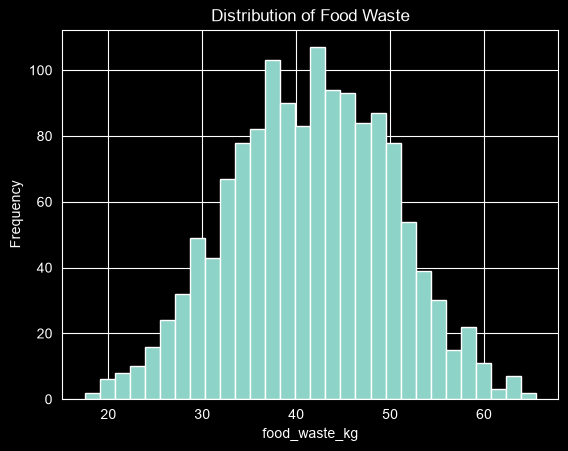

In [54]:
print("Skewness:", df["food_waste_kg"].skew()) # no

plt.hist(df["food_waste_kg"], bins=30)
plt.xlabel("food_waste_kg")
plt.ylabel("Frequency")
plt.title("Distribution of Food Waste")
plt.show() # has a little skew

In [56]:
y_log = np.log(df["food_waste_kg"])

print(y_log.head())

X = df[best_features]

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

# train
log_model = LinearRegression()
log_model.fit(X_train, y_train_log)

# predict
y_pred = log_model.predict(X_test)

# evaluate
mae = mean_absolute_error(y_test_log, y_pred)
mse = mean_squared_error(y_test_log, y_pred)
r2 = r2_score(y_test_log, y_pred)

print("Log model:")
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2) # 0.5903817020807407 it actually became a little better

0    3.591542
1    3.742894
2    3.684118
3    3.707456
4    3.604954
Name: food_waste_kg, dtype: float64
Log model:
MAE: 0.10647808620536113
MSE: 0.018471037635220396
R2: 0.5903817020807407


In [58]:
# Predict log(food_waste_kg)
y_pred_log = log_model.predict(X_test)

# Convert back to original food_waste_kg scale
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test_log)

print("Predictions:", y_pred_original[:10])
print("Actual:", y_test_original[:10])

residuals = y_test_original - y_pred_original

residual_df = pd.DataFrame({
    "Actual": y_test_original.values,
    "Predicted": y_pred_original,
    "Residual": residuals.values
})

residual_df["Absolute_Error"] = residual_df["Residual"].abs()

residual_df.head()

Predictions: [37.16399079 44.72427174 34.14761297 35.31158308 38.47078448 40.82848598
 47.64689843 60.50171297 39.44614158 44.05466479]
Actual: 51      41.81
289     45.11
677     38.98
1005    35.08
367     36.24
1156    46.07
566     49.27
534     58.63
582     53.86
1373    42.22
Name: food_waste_kg, dtype: float64


,Actual,Predicted,Residual,Absolute_Error
0,41.81,37.163991,4.646009,4.646009
1,45.11,44.724272,0.385728,0.385728
2,38.98,34.147613,4.832387,4.832387
3,35.08,35.311583,-0.231583,0.231583
4,36.24,38.470784,-2.230784,2.230784


In [59]:
largest_errors = residual_df.sort_values(
    "Absolute_Error",
    ascending=False
)

largest_errors.head(10)

,Actual,Predicted,Residual,Absolute_Error
256,23.80,41.338008,-17.538008,17.538008
263,39.43,55.584711,-16.154711,16.154711
116,27.77,42.520532,-14.750532,14.750532
8,53.86,39.446142,14.413858,14.413858
28,59.12,44.974245,14.145755,14.145755
80,45.01,58.640688,-13.630688,13.630688
88,51.60,37.991252,13.608748,13.608748
153,27.27,40.564403,-13.294403,13.294403
223,56.92,43.729857,13.190143,13.190143
81,50.16,37.357417,12.802583,12.802583


In [60]:
df["food_waste_kg"].sort_values(ascending=False).head(10)

984     65.51
901     64.11
1092    63.78
1415    63.65
261     63.12
1315    62.99
1207    62.61
672     62.48
1350    62.33
1163    61.46
Name: food_waste_kg, dtype: float64

In [61]:
df["food_waste_kg"].sort_values().head(10)

333     17.50
798     19.00
374     19.25
129     19.41
697     19.58
387     19.88
707     20.00
1287    20.49
605     20.75
734     20.83
Name: food_waste_kg, dtype: float64

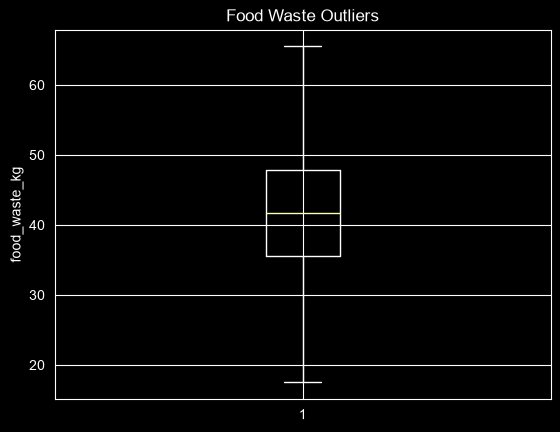

In [62]:
plt.boxplot(df["food_waste_kg"])
plt.ylabel("food_waste_kg")
plt.title("Food Waste Outliers")
plt.show()

## Cross validation

In [63]:
from sklearn.model_selection import KFold, cross_val_score

X = df[best_features]
y = df["food_waste_kg"]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R² scores:", cv_scores)

R² scores: [0.58959311 0.66121228 0.61408382 0.56687191 0.61883212]


In [64]:
print("Fold 1 R²:", cv_scores[0])
print("Fold 2 R²:", cv_scores[1])
print("Fold 3 R²:", cv_scores[2])
print("Fold 4 R²:", cv_scores[3])
print("Fold 5 R²:", cv_scores[4])

print("\nMean R²:", cv_scores.mean())
print("Std R² :", cv_scores.std())

Fold 1 R²: 0.5895931135745001
Fold 2 R²: 0.661212282845172
Fold 3 R²: 0.6140838154024704
Fold 4 R²: 0.5668719088696591
Fold 5 R²: 0.6188321189395252

Mean R²: 0.6101186479262652
Std R² : 0.03160311585554651


In [65]:
# single test vs cv test
print("Single test-set R²:", best_r2)
print("5-fold mean R²:", cv_scores.mean())

Single test-set R²: 0.5895931135744998
5-fold mean R²: 0.6101186479262652
